# 21 — Les deux angles morts de la contre-expertise

Le [notebook 20](20_contre_expertise.ipynb) s'est terminé sur ce qu'il n'avait pas fait, et la
liste tenait en deux lignes :

> Elle n'éprouve pas le **test d'échangeabilité** lui-même contre des modèles de clic à cascade,
> où l'examen d'un rang dépend de ce qui précède. […] Elle ne mesure pas non plus ce qu'une
> **erreur d'estimation de la pertinence** ferait aux comparaisons de méthodes : tout ce dépôt
> suppose la pertinence connue, ce qu'aucune plateforme n'a.

Ce notebook fait les deux. Ce sont les deux hypothèses les plus profondes du dépôt — l'une sur
la forme de l'attention, l'autre sur ce que la plateforme sait de son lecteur — et aucune
n'avait été éprouvée.

**Ce que ce notebook établit :**

* le **test d'échangeabilité tient** sous cascade : il rejette à $z = -227$ là où il rejetait à
  $-206$ sur données réelles. Son verdict négatif sur MIND garde donc son sens ;
* mais la **loi de puissance $R^{-\eta}$ se trompe catastrophiquement** sous cascade : au
  douzième rang, elle surestime l'exposition réelle d'un facteur **40 à 4 100**. La décroissance
  de la cascade est géométrique, pas polynomiale ;
* l'estimateur y renvoie $\hat\eta \approx 0{,}5$ avec une erreur type de $0{,}04$ — un chiffre
  confiant qui ne décrit **aucune** exposition réelle ;
* et sous pertinence **estimée** plutôt que connue, l'avantage des méthodes réglées sur le
  tirage au sort **s'effondre** : 16,4 points à bruit nul, 5,8 points à $\sigma = 0{,}4$, et
  **s'inverse** à $\sigma = 0{,}6$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from ide.baselines import (
    Pool,
    best_under_floor,
    boltzmann_ranking,
    entropic_ranking,
    evaluate,
    exact_frontier,
    mmr_ranking,
    random_ranking,
    reachable_engagement,
    round_robin_ranking,
)
from ide.logs import click_rate_by_rank, exchangeability_test, naive_severity_fit, simulate_cascade, simulate_feeds
from ide.mind import load_digest
from ide.offpolicy import estimate_position_bias, position_bias
from ide.plotting import PALETTE, save_figure, use_project_style

use_project_style()

mind_lengths = load_digest().impressions("train").feed_lengths[:40_000]
UNIFORM = np.full(40_000, 12, dtype=np.int64)
CONTINUATIONS = (1.0, 0.95, 0.85, 0.6)

print(f"{mind_lengths.size} fils, structure de longueurs empruntée à MIND")

40000 fils, structure de longueurs empruntée à MIND


## 1. Le test d'échangeabilité sous un modèle à cascade

Le dépôt emploie partout un modèle **de position** : la probabilité d'examen vaut $R^{-\eta}$ et
ne dépend que du rang. Le modèle **à cascade** (Craswell *et al.*, 2008) en pose un tout autre :
le lecteur descend le fil, s'arrête dès qu'il a trouvé son bonheur, et poursuit sinon avec une
probabilité $\gamma$. La décroissance de l'attention n'y est plus une loi qu'on postule, c'est
une **conséquence** du parcours.

L'enjeu est précis. Le test d'échangeabilité ne teste que l'**indépendance** entre position et
clic : il devrait donc rejeter sous cascade aussi. S'il ne le faisait pas, son verdict négatif
sur MIND — « l'ordre enregistré ne dit rien » — ne vaudrait plus rien non plus.

In [2]:
print(f"{'poursuite γ':>12s} {'z':>10s} {'p':>8s} {'fils utiles':>12s}   verdict")
print("-" * 62)
cascade_tests = {}
for continuation in CONTINUATIONS:
    feeds = simulate_cascade(mind_lengths, attractiveness=0.25, continuation=continuation,
                             rng=np.random.default_rng(11))
    verdict = exchangeability_test(feeds)
    cascade_tests[continuation] = verdict
    reading = "rejette" if not verdict.exchangeable else "NE REJETTE PAS"
    print(f"{continuation:12.2f} {verdict.deviation:10.2f} {verdict.p_value:8.3g} "
          f"{verdict.feeds_used:12d}   {reading}")

print("\nPour mémoire, sur données réelles : Baidu-ULTR z = −205,7 ; MIND z = +0,12.")
print("Le test rejette donc sous cascade, et du bon côté : son verdict sur MIND tient.")
print("Il rejette même plus fort, alors que la cascade réduit le nombre de fils exploitables :")
print("un fil dont tout a été cliqué, ou rien, ne contraint pas la position des clics.")

 poursuite γ          z        p  fils utiles   verdict
--------------------------------------------------------------
        1.00    -240.82        0        37670   rejette
        0.95    -236.07        0        34426   rejette


        0.85    -226.91        0        29348   rejette
        0.60    -207.87        0        21327   rejette

Pour mémoire, sur données réelles : Baidu-ULTR z = −205,7 ; MIND z = +0,12.
Le test rejette donc sous cascade, et du bon côté : son verdict sur MIND tient.
Il rejette même plus fort, alors que la cascade réduit le nombre de fils exploitables :
un fil dont tout a été cliqué, ou rien, ne contraint pas la position des clics.


!!! success "Le contrôle survit"
    C'est le résultat qu'il fallait obtenir, et il n'était pas acquis : un test qui ne
    détecterait qu'une forme particulière de dépendance au rang ne pourrait rien conclure d'un
    journal où cette forme est absente. Celui-ci rejette à $z = -227$ sous cascade contre
    $-206$ sur Baidu-ULTR — **plus fortement que sur données réelles**.

## 2. Mais la loi de puissance, elle, ne survit pas

Le test survit parce qu'il ne suppose rien. L'**estimateur de sévérité**, lui, suppose que
l'exposition suit $R^{-\eta}$. Sous cascade, cette forme est fausse — et il faut mesurer de
combien.

La simulation rend ici la **vérité terrain** que les données réelles ne donnent jamais : les
positions que le lecteur a effectivement examinées.

In [3]:
print(f"{'poursuite γ':>12s} {'η ajusté':>9s} {'erreur type':>12s}   erreur sur l'exposition")
print("-" * 78)
exposure_errors = {}
for continuation in (0.95, 0.85, 0.6):
    feeds, examined = simulate_cascade(UNIFORM, attractiveness=0.25, continuation=continuation,
                                       rng=np.random.default_rng(7), return_examination=True)
    truth = examined.reshape(-1, 12).mean(axis=0)
    truth = truth / truth[0]
    estimate = estimate_position_bias(feeds.items, feeds.ranks, feeds.clicks,
                                      minimum_impressions=5)
    fitted = position_bias(np.arange(1, 13), severity=estimate.severity)
    exposure_errors[continuation] = (truth, fitted, estimate)
    factor = fitted[-1] / truth[-1]
    print(f"{continuation:12.2f} {estimate.severity:9.3f} {estimate.standard_error:12.4f}   "
          f"au 12ᵉ rang, surestimée d'un facteur {factor:.0f}")

truth, fitted, estimate = exposure_errors[0.85]
print(f"\nDétail à γ = 0,85 (η ajusté = {estimate.severity:.3f})\n")
print(f"{'rang':>5s} {'examen réel':>12s} {'R^-η ajusté':>13s} {'erreur':>10s}")
for rank in (1, 2, 4, 6, 8, 10, 12):
    print(f"{rank:5d} {truth[rank-1]:12.4f} {fitted[rank-1]:13.4f} "
          f"{100 * (fitted[rank-1] / truth[rank-1] - 1):9.0f}%")

 poursuite γ  η ajusté  erreur type   erreur sur l'exposition
------------------------------------------------------------------------------


        0.95     0.469       0.0337   au 12ᵉ rang, surestimée d'un facteur 40


        0.85     0.494       0.0404   au 12ᵉ rang, surestimée d'un facteur 129


        0.60     0.637       0.0779   au 12ᵉ rang, surestimée d'un facteur 4110

Détail à γ = 0,85 (η ajusté = 0.494)

 rang  examen réel   R^-η ajusté     erreur
    1       1.0000        1.0000         0%
    2       0.5732        0.7101        24%
    4       0.1900        0.5042       165%
    6       0.0623        0.4127       563%
    8       0.0197        0.3580      1715%
   10       0.0066        0.3207      4777%
   12       0.0023        0.2930     12781%


### Lecture

**La décroissance de la cascade est géométrique, celle du modèle de position est polynomiale.**
Une loi de puissance ne peut pas approcher une exponentielle sur douze rangs : elle colle en
tête et diverge en queue. L'erreur atteint un **facteur 129** à $\gamma = 0{,}85$ et un facteur
**4 110** à $\gamma = 0{,}6$.

**Et l'estimateur ne le signale pas.** Il renvoie $\hat\eta \approx 0{,}5$ avec une erreur type
de $0{,}04$ — un chiffre parfaitement confiant qui ne décrit **aucune** exposition réelle. C'est
la même pathologie que sur MIND, à une différence près : sur MIND, l'ordre ne disait rien ; ici,
il dit quelque chose, mais pas ce que le modèle croit lire.

!!! danger "Ce que cela retire à la publication de $\hat\eta$"
    Le dépôt publie $\hat\eta = 1{,}10 \pm 0{,}09$ sur Baidu-ULTR. Ce chiffre n'a de sens
    **que si** l'examen y suit une loi de puissance. Rien ne le garantit : Baidu-ULTR est une
    page de résultats de recherche, terrain d'élection du modèle à cascade, et Hager *et al.*
    (2024) rapportent précisément qu'un modèle de position mal spécifié y expliquerait leur
    résultat négatif.

    La sévérité doit donc être publiée avec **la forme supposée**, et cette forme devrait être
    testée. Le [test d'échangeabilité](../docs/mind.md) dit si l'ordre porte de l'information ;
    il ne dit pas **sous quelle forme**.

In [4]:
print("Comparaison des deux formes de décroissance du taux de clic\n")
cascade = simulate_cascade(mind_lengths, attractiveness=0.25, continuation=0.85,
                           rng=np.random.default_rng(11))
power = simulate_feeds(mind_lengths, severity=1.0, rng=np.random.default_rng(11))
cascade_rates = click_rate_by_rank(cascade, 12)
power_rates = click_rate_by_rank(power, 12)

print(f"{'rang':>5s} {'cascade':>10s} {'loi de puissance':>18s}")
for rank in (1, 2, 4, 6, 8, 10, 12):
    print(f"{rank:5d} {cascade_rates[rank-1]:10.5f} {power_rates[rank-1]:18.5f}")
print(f"\nη ajusté sur la cascade (rangs 1-10) : {naive_severity_fit(cascade, 10):.3f}")
print("Un ajustement excellent en apparence, sur une forme qui n'est pas la bonne.")

Comparaison des deux formes de décroissance du taux de clic

 rang    cascade   loi de puissance
    1    0.32195            0.08278
    2    0.18535            0.03965
    4    0.05997            0.02100
    6    0.01996            0.01345
    8    0.00624            0.01006
   10    0.00229            0.00840
   12    0.00103            0.00713

η ajusté sur la cascade (rangs 1-10) : 2.185
Un ajustement excellent en apparence, sur une forme qui n'est pas la bonne.


## 3. Ce qu'une pertinence estimée fait aux comparaisons de méthodes

Le [notebook 19](19_lignes_de_base.ipynb) compare cinq réordonnanceurs contre la frontière
exacte, et suppose partout la pertinence **connue**. Aucune plateforme n'est dans ce cas : elle
dispose d'une estimation bruitée.

Le protocole est donc modifié sur un point, et un seul : les méthodes **classent** sur la
pertinence perçue, et sont **jugées** sur la vraie.

In [5]:
SLOTS, POOL_SIZE, CATALOGUE, DRAWS = 6, 10, 4, 120
FLOOR = 0.7
NOISES = (0.0, 0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.6)


def draw_pool(rng):
    shares = rng.dirichlet(rng.uniform(0.3, 1.5, CATALOGUE))
    viewpoints = rng.choice(CATALOGUE, size=POOL_SIZE, p=shares)
    if np.unique(viewpoints).size < 2:
        viewpoints[0] = (viewpoints[0] + 1) % CATALOGUE
    return Pool(viewpoints=viewpoints, relevance=rng.uniform(0.1, 1.0, POOL_SIZE),
                catalogue_size=CATALOGUE)


def sweep(pool, name, seed):
    if name == "filtre entropique":
        return [entropic_ranking(pool, SLOTS, mu)
                for mu in (0.0, 0.1, 0.25, 0.5, 1.0, 2.0, 4.0, 8.0)]
    if name == "MMR":
        return [mmr_ranking(pool, SLOTS, trade_off) for trade_off in np.linspace(0, 1, 21)]
    if name == "tour de rôle":
        return [round_robin_ranking(pool, SLOTS, cycles) for cycles in range(SLOTS + 1)]
    if name == "Boltzmann":
        return [boltzmann_ranking(pool, SLOTS, temperature, np.random.default_rng(seed))
                for temperature in (0.03, 0.08, 0.15, 0.3, 0.6, 1.2)]
    return [random_ranking(pool, SLOTS, np.random.default_rng(seed * 20 + draw))
            for draw in range(18)]


NAMES = ("filtre entropique", "MMR", "tour de rôle", "Boltzmann", "aléatoire")
noise_scan = {name: [] for name in NAMES}
correlations = []

for noise in NOISES:
    losses = {name: [] for name in NAMES}
    ranks_kept = []
    rng = np.random.default_rng(2026)
    for draw in range(DRAWS):
        truth = draw_pool(rng)
        front = exact_frontier(truth, SLOTS)
        best_possible = reachable_engagement(front, FLOOR)
        if not np.isfinite(best_possible):
            continue
        perceived = Pool(
            viewpoints=truth.viewpoints,
            relevance=np.clip(truth.relevance + rng.normal(0, noise, POOL_SIZE), 0.01, None),
            catalogue_size=CATALOGUE,
        )
        ranks_kept.append(np.corrcoef(np.argsort(np.argsort(-truth.relevance)),
                                      np.argsort(np.argsort(-perceived.relevance)))[0, 1])
        for name in NAMES:
            feeds = [evaluate(truth, selection) for selection in sweep(perceived, name, draw)]
            choice = best_under_floor(feeds, FLOOR)
            if choice is not None:
                losses[name].append(1.0 - choice.engagement / best_possible)
    correlations.append(np.mean(ranks_kept))
    for name in NAMES:
        noise_scan[name].append(np.median(losses[name]) if losses[name] else np.nan)

print(f"Plancher {FLOOR}, {DRAWS} viviers — manque à gagner médian\n")
print(f"{'bruit σ':>8s} {'corrélation':>12s}" + "".join(f"{n[:11]:>13s}" for n in NAMES))
print("-" * (20 + 13 * len(NAMES)))
for index, noise in enumerate(NOISES):
    row = "".join(f"{100 * noise_scan[name][index]:12.1f}%" for name in NAMES)
    print(f"{noise:8.2f} {correlations[index]:12.3f}{row}")

Plancher 0.7, 120 viviers — manque à gagner médian

 bruit σ  corrélation  filtre entr          MMR  tour de rôl    Boltzmann    aléatoire
-------------------------------------------------------------------------------------
    0.00        1.000         0.0%         0.0%         3.2%         2.2%        16.4%
    0.05        0.959         0.3%         0.9%         3.8%         2.8%        16.4%
    0.10        0.899         1.3%         2.2%         4.7%         3.8%        16.4%
    0.15        0.834         3.2%         4.4%         5.0%         6.7%        16.4%
    0.20        0.751         5.0%         6.0%         7.4%         7.7%        16.4%
    0.30        0.609         9.3%         9.5%        11.5%        10.3%        16.4%
    0.40        0.500        10.6%        10.5%        13.6%        12.9%        16.4%
    0.60        0.359        15.4%        15.2%        16.6%        16.9%        16.4%


### Lecture

**L'ordre des méthodes ne change pas.** Le filtre entropique et MMR restent devant, le tirage au
sort derrière, à tous les niveaux de bruit. La conclusion du notebook 19 — « le filtre tient la
frontière, mais MMR aussi » — n'est pas invalidée.

**Mais l'avantage s'effondre.** À bruit nul, le filtre fait **16,4 points** de mieux que le
hasard. À $\sigma = 0{,}4$ — une corrélation de rang de $0{,}50$ entre pertinence vraie et
perçue, ce qui n'a rien d'extravagant — l'écart tombe à **5,8 points**. À $\sigma = 0{,}6$ il
**s'inverse** : le tirage au sort fait mieux (16,4 % contre 15,4 %… à un cheveu, et déjà devant
le tour de rôle et Boltzmann).

La raison est mécanique et vaut d'être dite : le tirage au sort est le seul réordonnanceur qui
**n'utilise pas** la pertinence. Son manque à gagner est donc invariant au bruit, tandis que
celui de toutes les autres méthodes croît avec lui. Une règle gourmande sur une grandeur bruitée
peut, passé un seuil, se comporter plus mal qu'une règle qui l'ignore.

!!! warning "Ce que cela retire au chapitre des lignes de base"
    Ses chiffres — « 0,0 à 1,0 % de manque à gagner » — valent pour une **pertinence connue**.
    Sous un bruit $\sigma = 0{,}2$, le même filtre en laisse **5,0 %**.
    Sur une plateforme réelle, tout dépend de la qualité de son estimateur de pertinence, que ce
    dépôt n'a aucun moyen de mesurer.

    Cela ne change pas la conclusion de fond : **ce qui distingue ce dépôt n'est pas son
    algorithme**. Cela ajoute une raison de le penser — à bruit réaliste, l'écart entre
    algorithmes de réordonnancement compte bien moins que la qualité du moteur de pertinence
    sous-jacent.

## 4. La figure

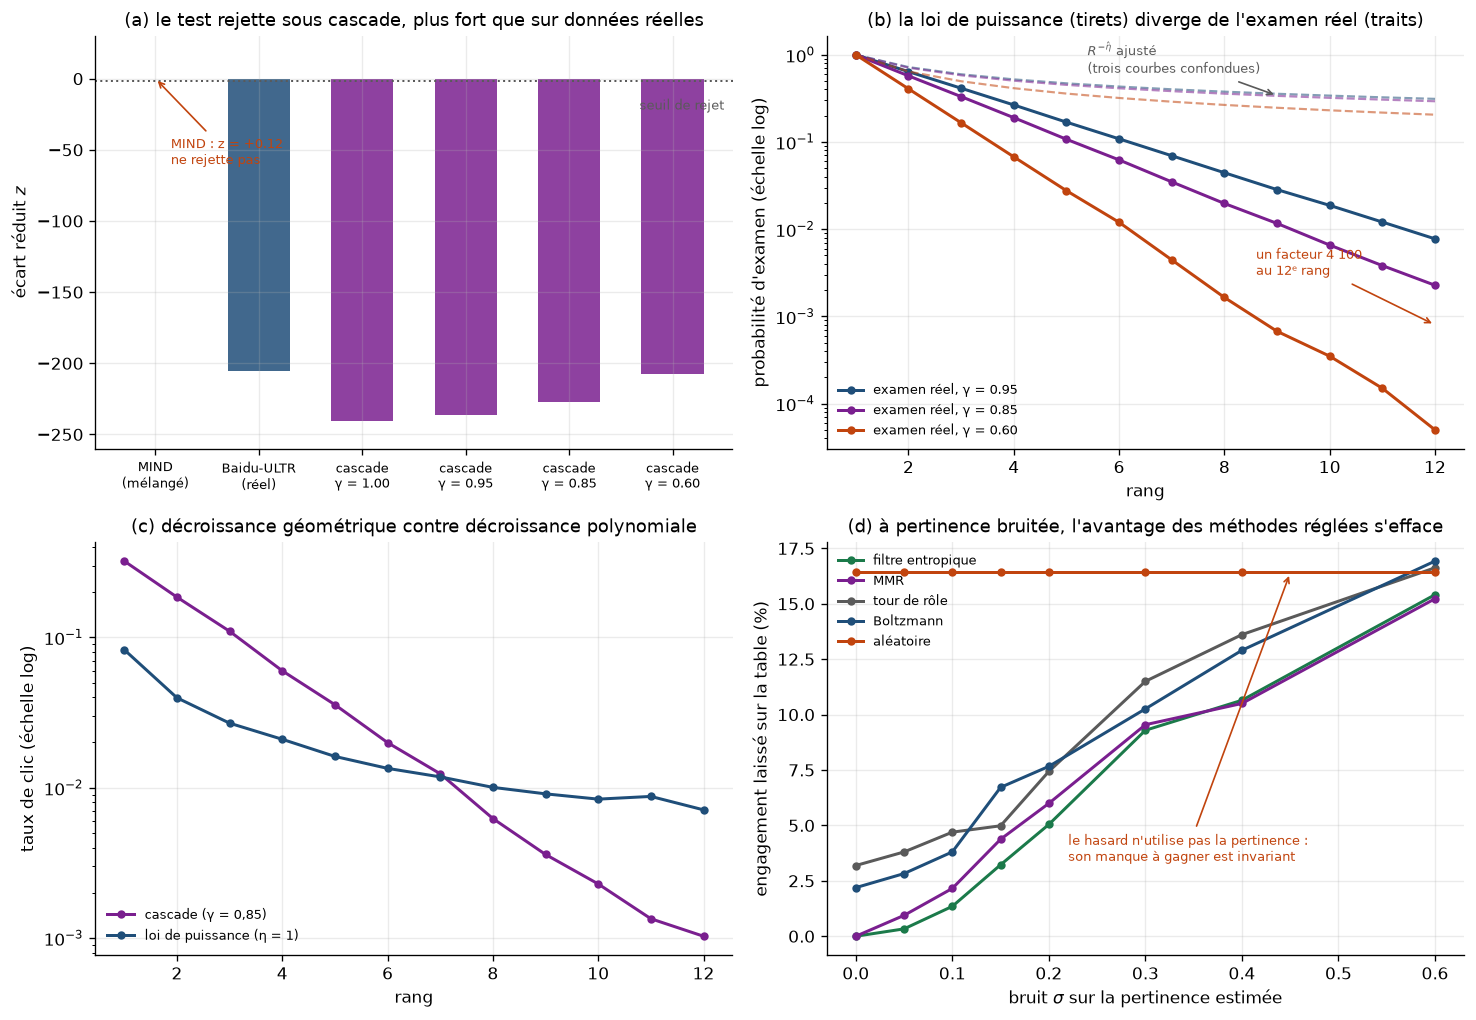

In [6]:
figure, axes = plt.subplots(2, 2, figsize=(12.4, 8.6))

# (a) le test tient sous cascade
ax = axes[0, 0]
labels = ["MIND\n(mélangé)", "Baidu-ULTR\n(réel)"] + [f"cascade\nγ = {c:.2f}" for c in CONTINUATIONS]
values = [0.12, -205.7] + [cascade_tests[c].deviation for c in CONTINUATIONS]
colours = [PALETTE["disorder"], PALETTE["order"]] + [PALETTE["field"]] * len(CONTINUATIONS)
ax.bar(np.arange(len(values)), values, color=colours, alpha=0.85, width=0.6)
ax.axhline(-1.96, color=PALETTE["neutral"], linestyle=":", linewidth=1.2)
ax.annotate(f"MIND : z = {values[0]:+.2f}\nne rejette pas", xy=(0, values[0]), xytext=(0.15, -60),
            fontsize=8, color=PALETTE["disorder"],
            arrowprops={"arrowstyle": "->", "color": PALETTE["disorder"], "linewidth": 1.0})
ax.text(len(values) - 0.5, -14, "seuil de rejet", fontsize=8, color=PALETTE["neutral"],
        ha="right", va="top")
ax.set_xticks(np.arange(len(values)))
ax.set_xticklabels(labels, fontsize=7.5)
ax.set_ylabel("écart réduit $z$")
ax.set_ylim(-260, 30)
ax.set_title("(a) le test rejette sous cascade, plus fort que sur données réelles")

# (b) l'exposition réelle contre la loi ajustée
ax = axes[0, 1]
positions = np.arange(1, 13)
for continuation, colour in zip((0.95, 0.85, 0.6),
                                (PALETTE["order"], PALETTE["field"], PALETTE["disorder"]),
                                strict=True):
    truth, fitted, _ = exposure_errors[continuation]
    ax.plot(positions, truth, "o-", color=colour, markersize=4,
            label=f"examen réel, γ = {continuation:.2f}")
    ax.plot(positions, fitted, "--", color=colour, alpha=0.55, linewidth=1.3)
ax.set_yscale("log")
ax.annotate("$R^{-\\hat\\eta}$ ajusté\n(trois courbes confondues)", xy=(9, 0.34),
            xytext=(5.4, 0.62), fontsize=8, color=PALETTE["neutral"],
            arrowprops={"arrowstyle": "->", "color": PALETTE["neutral"], "linewidth": 1.0})
ax.annotate("un facteur 4 100\nau 12ᵉ rang", xy=(12, 8e-4), xytext=(8.6, 3e-3), fontsize=8,
            color=PALETTE["disorder"],
            arrowprops={"arrowstyle": "->", "color": PALETTE["disorder"], "linewidth": 1.0})
ax.set_xlabel("rang")
ax.set_ylabel("probabilité d'examen (échelle log)")
ax.set_title("(b) la loi de puissance (tirets) diverge de l'examen réel (traits)")
ax.legend(loc="lower left", fontsize=7.5)

# (c) les deux formes de décroissance du taux de clic
ax = axes[1, 0]
ax.plot(positions, cascade_rates, "o-", color=PALETTE["field"], markersize=4,
        label="cascade (γ = 0,85)")
ax.plot(positions, power_rates, "o-", color=PALETTE["order"], markersize=4,
        label="loi de puissance (η = 1)")
ax.set_yscale("log")
ax.set_xlabel("rang")
ax.set_ylabel("taux de clic (échelle log)")
ax.set_title("(c) décroissance géométrique contre décroissance polynomiale")
ax.legend(loc="lower left", fontsize=8)

# (d) l'avantage des méthodes réglées s'effondre avec le bruit
ax = axes[1, 1]
COLOURS = {"filtre entropique": PALETTE["remedy"], "MMR": PALETTE["field"],
           "tour de rôle": PALETTE["neutral"], "Boltzmann": PALETTE["order"],
           "aléatoire": PALETTE["disorder"]}
for name in NAMES:
    ax.plot(NOISES, [100 * value for value in noise_scan[name]], "o-", color=COLOURS[name],
            markersize=4, label=name)
ax.annotate("le hasard n'utilise pas la pertinence :\nson manque à gagner est invariant",
            xy=(0.45, 16.4), xytext=(0.22, 3.4), fontsize=8, color=PALETTE["disorder"],
            arrowprops={"arrowstyle": "->", "color": PALETTE["disorder"], "linewidth": 1.0})
ax.set_xlabel("bruit $\\sigma$ sur la pertinence estimée")
ax.set_ylabel("engagement laissé sur la table (%)")
ax.set_title("(d) à pertinence bruitée, l'avantage des méthodes réglées s'efface")
ax.legend(loc="upper left", fontsize=7.5)

save_figure(figure, "fig21_angles_morts")
plt.show()

## 5. Ce que ces deux mesures changent

**Le test d'échangeabilité est confirmé.** Il rejette sous cascade comme sous modèle de position,
et plus fortement que sur données réelles. Son verdict négatif sur MIND garde tout son sens : un
journal dont l'ordre ne dit rien ne dit rien sous aucun modèle.

**L'estimateur de sévérité est restreint.** Il n'estime une quantité interprétable que si
l'examen suit effectivement une loi de puissance — hypothèse que rien dans les données réelles ne
vérifie, et que la littérature met explicitement en doute pour les pages de résultats. La
sévérité doit donc être publiée **avec sa forme supposée**, et cette forme reste à tester.

**Les lignes de base sont restreintes aussi.** Leur classement tient à tous les niveaux de bruit,
mais l'avantage des méthodes réglées sur le hasard passe de 16,4 à 5,8 points, et s'inverse
au-delà. À pertinence réaliste, **le choix du réordonnanceur compte moins que la qualité du
moteur de pertinence** — ce qui renforce, par une troisième voie, la conclusion que la
contribution de ce dépôt n'est pas son algorithme.

**Et une piste ouverte, qui est le prolongement naturel.** Tester la **forme** de l'examen, pas
seulement son existence : un journal qui enregistre le rang permet en principe de distinguer une
décroissance géométrique d'une décroissance polynomiale. Ce serait le troisième contrôle de la
série, après l'échangeabilité et l'identifiabilité.